# Gasoil Other Reportables — Correlation with Other Trader Categories

Same analysis as WTI, but for ICE Gasoil.

Data source: ICE Europe COT report (disaggregated, futures+options
combined where available, futures-only fallback pre-2013).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load Gasoil ICE COT (disaggregated)

In [2]:
ICE_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/ice_cot.csv'

ice = pd.read_csv(ICE_PATH, low_memory=False)

# Use combined (F+O) where available, fallback to futures-only
# Combined available from 2013-03-12 onwards
BRENT_COMBINED = 'ICE Gasoil Futures and Options - ICE Futures Europe'
BRENT_FUTURES  = 'ICE Gasoil Futures - ICE Futures Europe'

br_combined = ice[ice['Market_and_Exchange_Names'] == BRENT_COMBINED].copy()
br_futures  = ice[ice['Market_and_Exchange_Names'] == BRENT_FUTURES].copy()

# Parse dates
for df in [br_combined, br_futures]:
    df['as_of_date'] = pd.to_datetime(df['As_of_Date_Form_MM/DD/YYYY'])

# Use combined where available, futures-only for earlier dates
combined_start = br_combined['as_of_date'].min()
br_early = br_futures[br_futures['as_of_date'] < combined_start]
br = pd.concat([br_early, br_combined], ignore_index=True)
br.sort_values('as_of_date', inplace=True)
br.reset_index(drop=True, inplace=True)

# Release date
days_ahead = (4 - br['as_of_date'].dt.dayofweek) % 7
br['release_date'] = br['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
br['open_interest'] = pd.to_numeric(br['Open_Interest_All'], errors='coerce')

print(f'Gasoil rows: {len(br)}')
print(f'  Futures-only (pre-{combined_start.date()}): {len(br_early)}')
print(f'  Combined (F+O): {len(br_combined)}')
print(f'Date range: {br["as_of_date"].min().date()} -> {br["as_of_date"].max().date()}')

Gasoil rows: 845
  Futures-only (pre-2013-03-12): 228
  Combined (F+O): 617
Date range: 2011-01-04 -> 2025-12-30


In [3]:
# ICE column names (note capitalisation differs from CFTC)
CATEGORIES = {
    'Producer/Merchant': ('Prod_Merc_Positions_Long_All', 'Prod_Merc_Positions_Short_All'),
    'Swap Dealers':      ('Swap_Positions_Long_All', 'Swap__Positions_Short_All'),
    'Managed Money':     ('M_Money_Positions_Long_All', 'M_Money_Positions_Short_All'),
    'Other Reportables': ('Other_Rept_Positions_Long_All', 'Other_Rept_Positions_Short_All'),
    'Non-Reportables':   ('NonRept_Positions_Long_All', 'NonRept_Positions_Short_All'),
}

COLORS = {
    'Producer/Merchant': 'tab:red',
    'Swap Dealers':      'tab:purple',
    'Managed Money':     'tab:blue',
    'Other Reportables': 'tab:orange',
    'Non-Reportables':   'tab:grey',
}

OTHERS_VS = [c for c in CATEGORIES if c != 'Other Reportables']

net_raw = {}
net_oi  = {}
oi = br['open_interest'].values

for cat, (long_col, short_col) in CATEGORIES.items():
    long_pos  = pd.to_numeric(br[long_col], errors='coerce').values
    short_pos = pd.to_numeric(br[short_col], errors='coerce').values
    net = long_pos - short_pos
    net_raw[cat] = net
    net_oi[cat]  = net / oi * 100

dates = br['as_of_date'].values

raw_df = pd.DataFrame(net_raw, index=dates).sort_index()
oi_df  = pd.DataFrame(net_oi, index=dates).sort_index()

raw_chg = raw_df.diff().dropna()
oi_chg  = oi_df.diff().dropna()

print(f'Weekly changes: {len(raw_chg)} weeks')

Weekly changes: 635 weeks


## 2. Net positioning levels

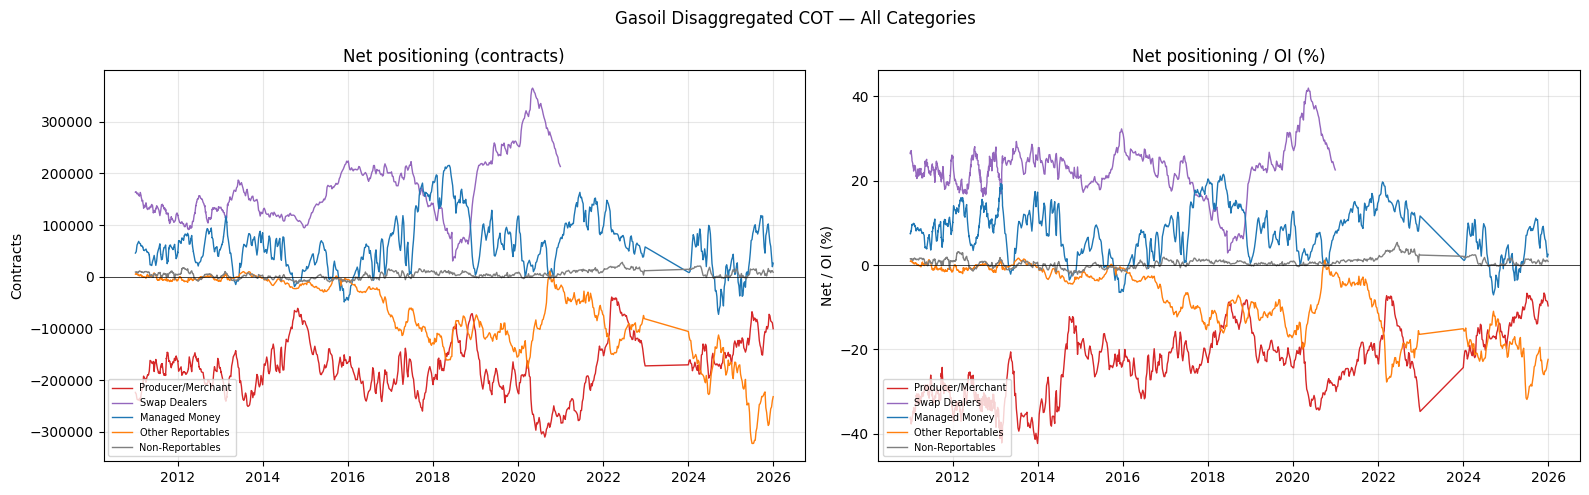

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for cat in CATEGORIES:
    axes[0].plot(raw_df.index, raw_df[cat], label=cat, color=COLORS[cat], lw=1)
    axes[1].plot(oi_df.index, oi_df[cat], label=cat, color=COLORS[cat], lw=1)

axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('Net positioning (contracts)')
axes[0].set_ylabel('Contracts')
axes[0].legend(fontsize=7, loc='lower left')

axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('Net positioning / OI (%)')
axes[1].set_ylabel('Net / OI (%)')
axes[1].legend(fontsize=7, loc='lower left')

plt.suptitle('Gasoil Disaggregated COT — All Categories', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Full-sample correlations

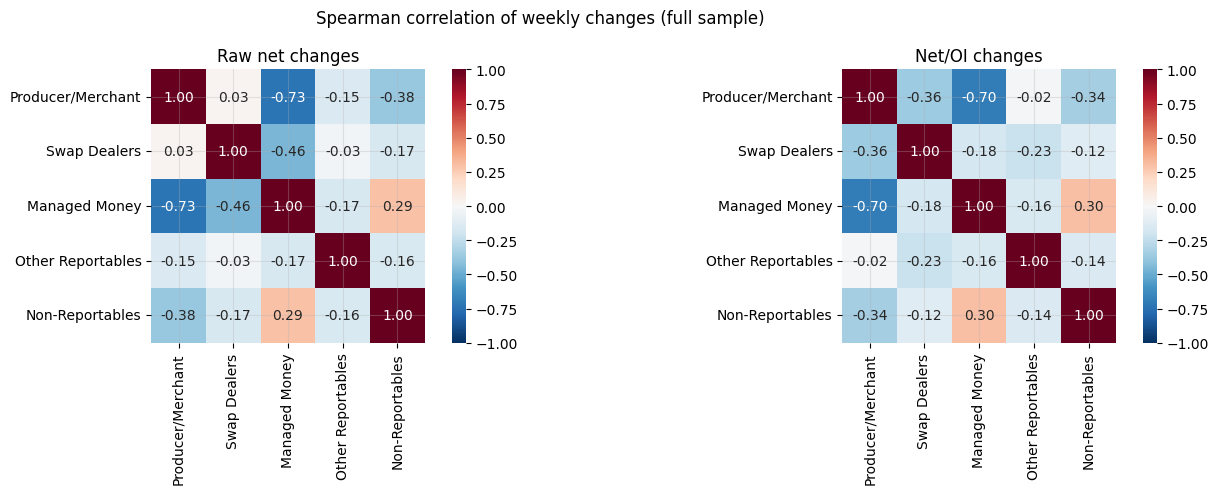

Category                    Raw net chg    Net/OI chg
-------------------------------------------------------
Producer/Merchant                -0.147        -0.017
Swap Dealers                     -0.033        -0.225
Managed Money                    -0.165        -0.162
Non-Reportables                  -0.160        -0.145


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, chg_df, title in [
    (axes[0], raw_chg, 'Raw net changes'),
    (axes[1], oi_chg,  'Net/OI changes'),
]:
    corr = chg_df.corr(method='spearman')
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title(title)

plt.suptitle('Spearman correlation of weekly changes (full sample)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'{"Category":25s}  {"Raw net chg":>12s}  {"Net/OI chg":>12s}')
print('-' * 55)
for cat in OTHERS_VS:
    rho_raw, _ = sp_stats.spearmanr(raw_chg['Other Reportables'], raw_chg[cat])
    rho_oi, _  = sp_stats.spearmanr(oi_chg['Other Reportables'], oi_chg[cat])
    print(f'{cat:25s}  {rho_raw:+12.3f}  {rho_oi:+12.3f}')

## 4. Rolling 52-week correlation

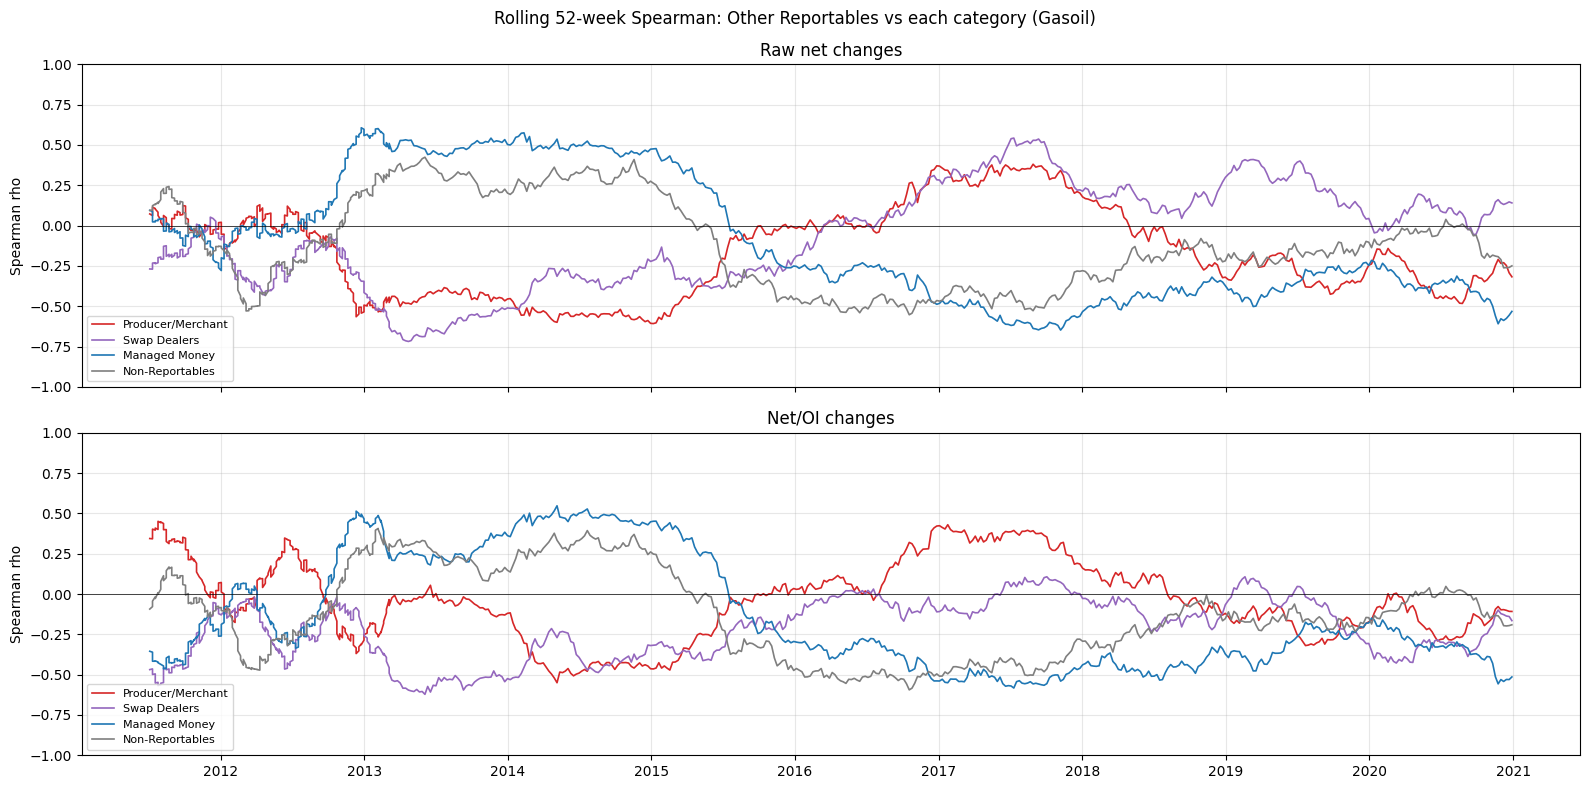

In [6]:
WINDOW = 52

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, chg_df, title in [
    (axes[0], raw_chg, 'Raw net changes'),
    (axes[1], oi_chg,  'Net/OI changes'),
]:
    other = chg_df['Other Reportables'].values
    for cat in OTHERS_VS:
        vals = chg_df[cat].values
        rhos = [
            sp_stats.spearmanr(other[i-WINDOW:i], vals[i-WINDOW:i]).statistic
            if i >= WINDOW else float('nan')
            for i in range(len(other))
        ]
        ax.plot(chg_df.index, rhos, label=cat, color=COLORS[cat], lw=1.2)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f'{title}')
    ax.set_ylabel('Spearman rho')
    ax.set_ylim(-1, 1)
    ax.legend(loc='lower left', fontsize=8)

plt.suptitle(f'Rolling {WINDOW}-week Spearman: Other Reportables vs each category (Gasoil)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Year-by-year correlation

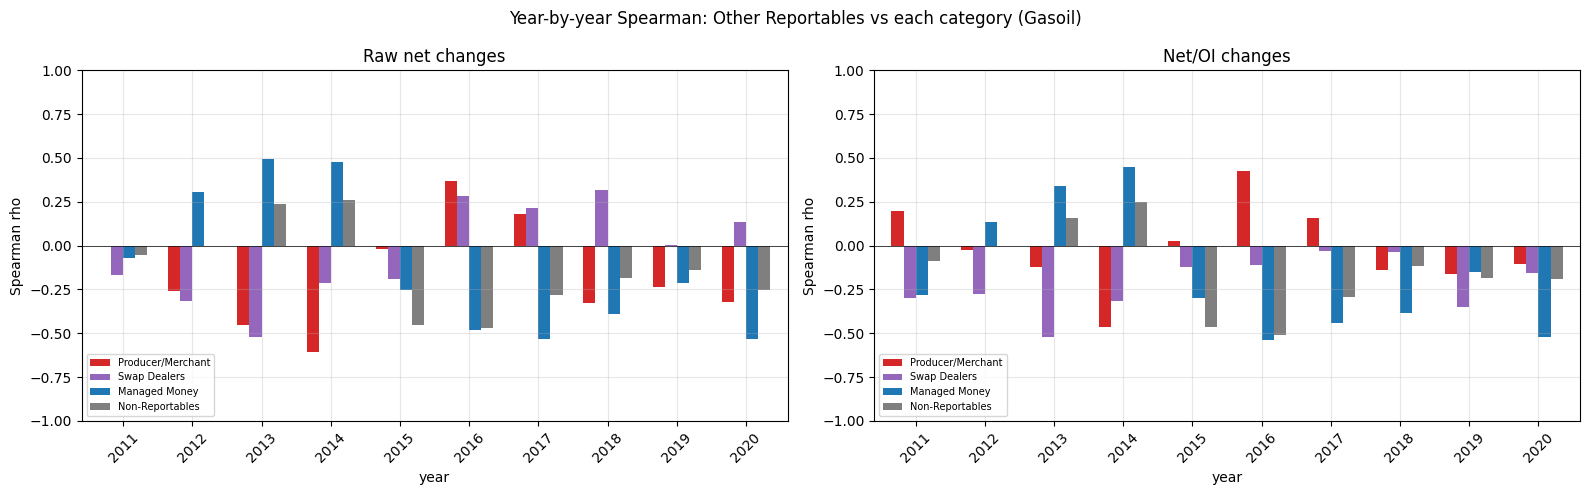

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, chg_df, title in [
    (axes[0], raw_chg, 'Raw net changes'),
    (axes[1], oi_chg,  'Net/OI changes'),
]:
    chg_yr = chg_df.copy()
    chg_yr['year'] = chg_yr.index.year

    yearly = []
    for year, grp in chg_yr.groupby('year'):
        if len(grp) < 20:
            continue
        row = {'year': year}
        for cat in OTHERS_VS:
            rho, _ = sp_stats.spearmanr(grp['Other Reportables'], grp[cat])
            row[cat] = rho
        yearly.append(row)

    yr_df = pd.DataFrame(yearly).set_index('year')
    yr_df.plot.bar(ax=ax, color=[COLORS[c] for c in yr_df.columns], width=0.7)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(title)
    ax.set_ylabel('Spearman rho')
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=7, loc='lower left')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.suptitle('Year-by-year Spearman: Other Reportables vs each category (Gasoil)', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
for chg_df, label in [(raw_chg, 'RAW NET CHANGES'), (oi_chg, 'NET/OI CHANGES')]:
    chg_yr = chg_df.copy()
    chg_yr['year'] = chg_yr.index.year
    yearly = []
    for year, grp in chg_yr.groupby('year'):
        if len(grp) < 20:
            continue
        row = {'year': year}
        for cat in OTHERS_VS:
            rho, _ = sp_stats.spearmanr(grp['Other Reportables'], grp[cat])
            row[cat] = rho
        yearly.append(row)
    yr_df = pd.DataFrame(yearly).set_index('year')
    print(f'\n=== {label} ===')
    print(yr_df.round(3).to_string())


=== RAW NET CHANGES ===
      Producer/Merchant  Swap Dealers  Managed Money  Non-Reportables
year                                                                 
2011             -0.003        -0.167         -0.068           -0.053
2012             -0.261        -0.317          0.306           -0.001
2013             -0.456        -0.521          0.492            0.235
2014             -0.607        -0.216          0.476            0.263
2015             -0.017        -0.188         -0.253           -0.451
2016              0.369         0.283         -0.482           -0.468
2017              0.178         0.214         -0.533           -0.279
2018             -0.327         0.318         -0.390           -0.188
2019             -0.238         0.001         -0.215           -0.137
2020             -0.322         0.136         -0.534           -0.255

=== NET/OI CHANGES ===
      Producer/Merchant  Swap Dealers  Managed Money  Non-Reportables
year                                     